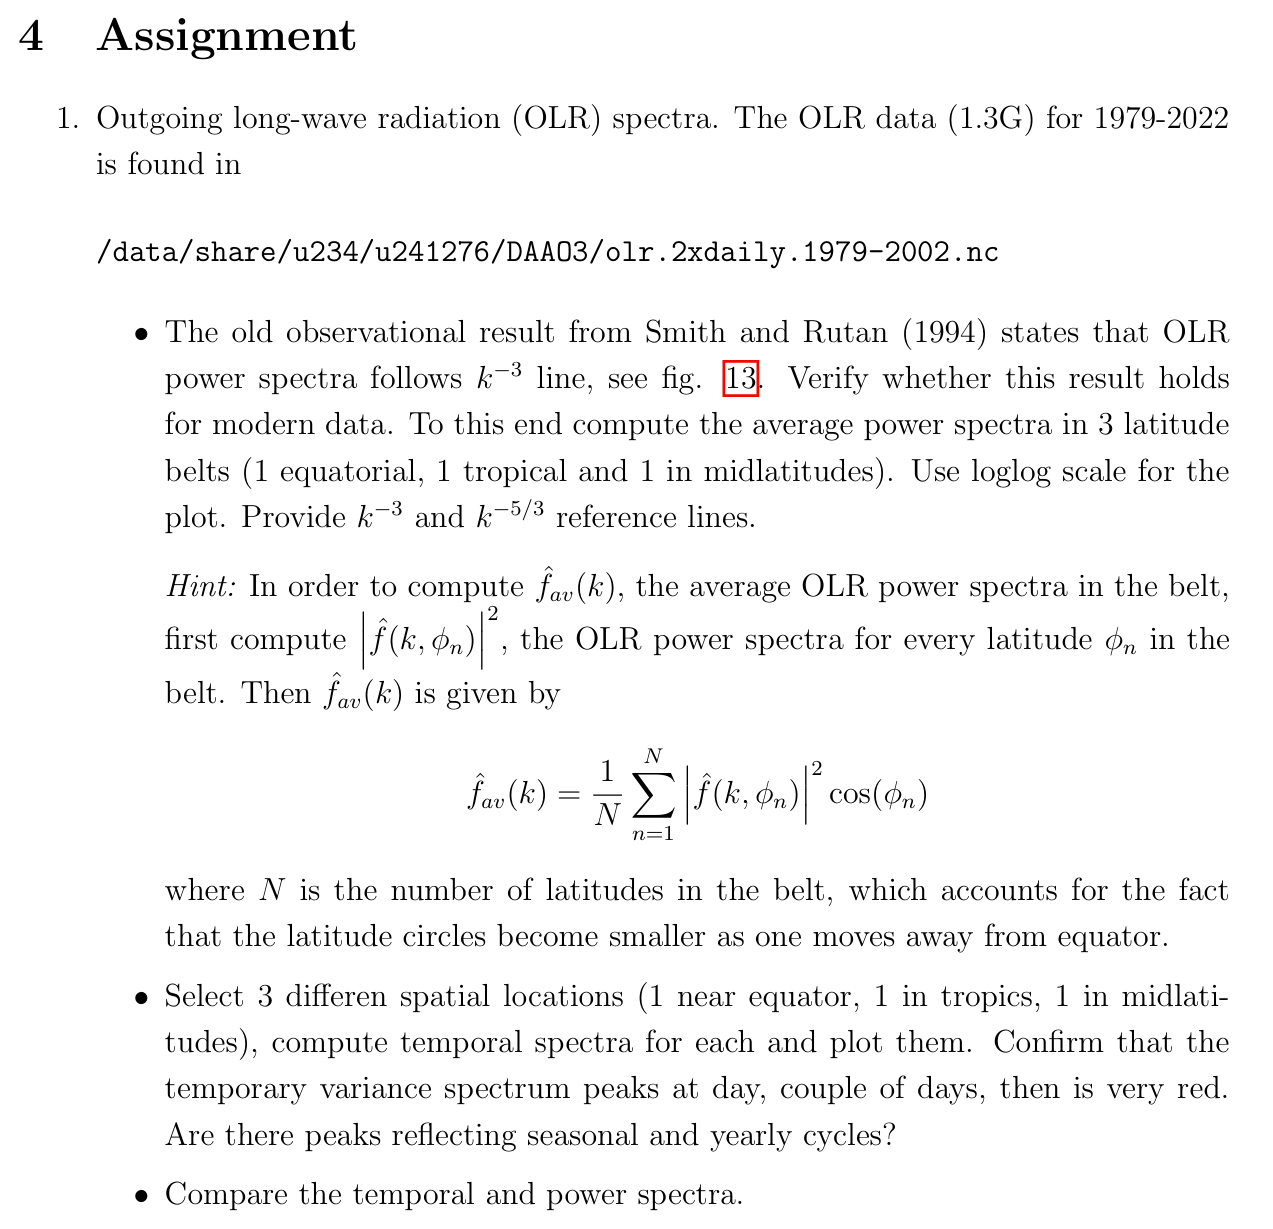

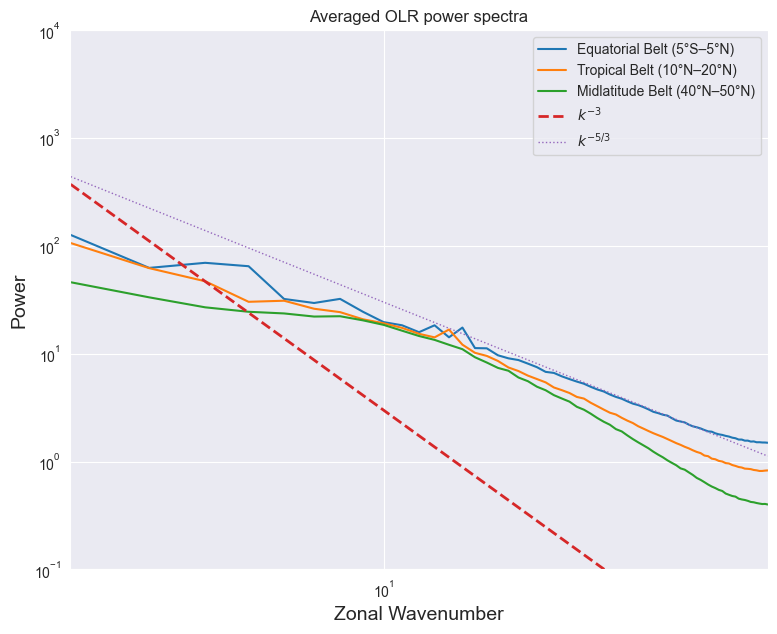

In [69]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.fft as fft
import xarray as xr


path = Path("olr.2xdaily.1979-2022.nc")

ds = xr.open_dataset(path, engine='scipy')


olr = ds['olr']
lats = ds['lat'].values
lons = ds['lon'].values


lon_idx = olr.dims.index('lon')
time_idx = olr.dims.index('time')

f_hat = fft.rfft(
    olr,
    axis=lon_idx,
    norm='forward'
)

# Compute mean OLR power spectra.
power = np.abs(f_hat)**2
power_mean = power.mean(axis=time_idx)

# Define latitude belts:
latitude_belts = {
    "Equatorial Belt (5°S–5°N)": (-5, 5),
    "Tropical Belt (10°N–20°N)": (15, 25),
    "Midlatitude Belt (40°N–50°N)": (40, 50)
}

# Compute the cosine-weighted spectra.
power_spectra = {}

for belt, (lat_min, lat_max) in latitude_belts.items():

    mask = (lats >= lat_min) & (lats <= lat_max)

    weights = np.cos(np.deg2rad(lats[mask]))

    power_spectrum = np.average(
        power_mean[mask, :],
        axis=time_idx,
        weights=weights
    )

    power_spectra[belt] = power_spectrum

# Wavenumber axis.
k = np.arange(power_mean.shape[1])
k = k[1:]


# Plotting
fig, ax = plt.subplots(figsize=(9, 7))

for belt, spectrum in power_spectra.items():

    ax.loglog(
        k,
        spectrum[1:],
        label=belt
    )

c1 = 3000
m1 = -3
kref = k.astype(float)
k_ref_1 = c1 * kref ** m1

ax.loglog(
    k,
    k_ref_1,
    lw=2,
    linestyle="--",
    label=r"$k^{-3}$"
)

c2 = 1400
m2 = -5/3
k_ref_2 = c2 * kref ** m2

ax.loglog(
    k,
    k_ref_2,
    lw=1,
    linestyle=":",
    label=r"$k^{-5/3}$"
)

ax.set_xlabel("Zonal Wavenumber", fontsize=14)
ax.set_ylabel("Power", fontsize=14)
ax.set_title("Averaged OLR power spectra")

ax.set_xlim(k[1:].min(), k[1:].max())
ax.set_ylim(10e-2, 10e3)

ax.legend()

plt.show()


In [42]:
k

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72])

In [17]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 73, lon: 144, time: 32142)
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 257kB 1979-01-01T06:00:00 ... 2022-12-31T1...
Data variables:
    olr      (time, lat, lon) float32 1GB 153.5 153.5 153.5 ... 166.0 166.0
Attributes:
    title:             NOAA Interpolated OLR
    history:           Fri Apr 21 11:19:19 2023: ncpdq -a -lat olr.2xdaily.19...
    source_file:       /Volumes/macdata/data8/olr.2x.7922.b
    source_file_info:  1362306528 Jan 25 21:06 /Volumes/macdata/data8/olr.2x....
    NCO:               netCDF Operators version 4.8.1 (Homepage = http://nco....
    References:        https://www.psl.noaa.gov/data/gridded/data.interp_OLR....
    dataset_title:     NOAA Interpolated Outgoing Longwave Radiation (OLR)
    Citation:          Liebmann and Smith: June 2006: Description of a Comple...

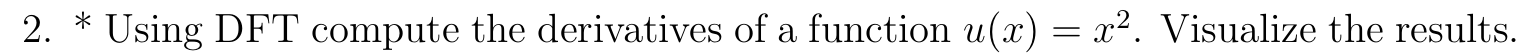

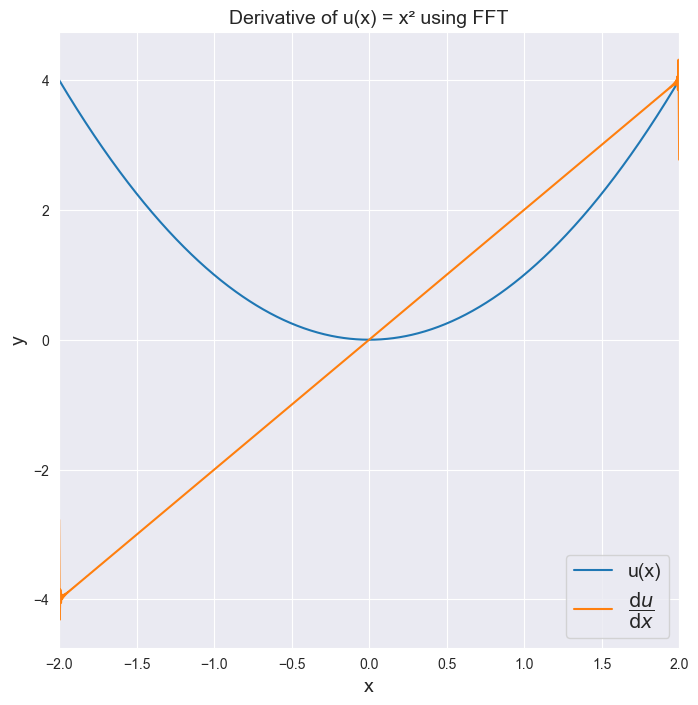

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fftpack import diff


L = 2
x = np.linspace(-L, L, 1001)

u = x ** 2

dudx = diff(u, period=2*L)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(x, u, label="u(x)")
ax.plot(x, dudx, label=r"$\dfrac{\mathrm{d}u}{\mathrm{d}x}$")

ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
ax.set_title("Derivative of u(x) = x² using FFT", fontsize=14)

ax.set_xlim(-L, L)

ax.legend(fontsize=14)

plt.show()